In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf



,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,Потенциал развития застройки общественно-деловой зоны,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки транспортной зоны,Срок рекультивации территории,Стоимость рекультивации территории
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",0.0,2.0,5.0,-2.66,5.0,4.0,2.0,0.2,0.05,...,2.0,3.0,1.0,4.0,3.0,3.0,4.0,4.0,6324.0,2.284321e+09


/home/mvin/Urbanomy/urbanomy/methods/investment_potential.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


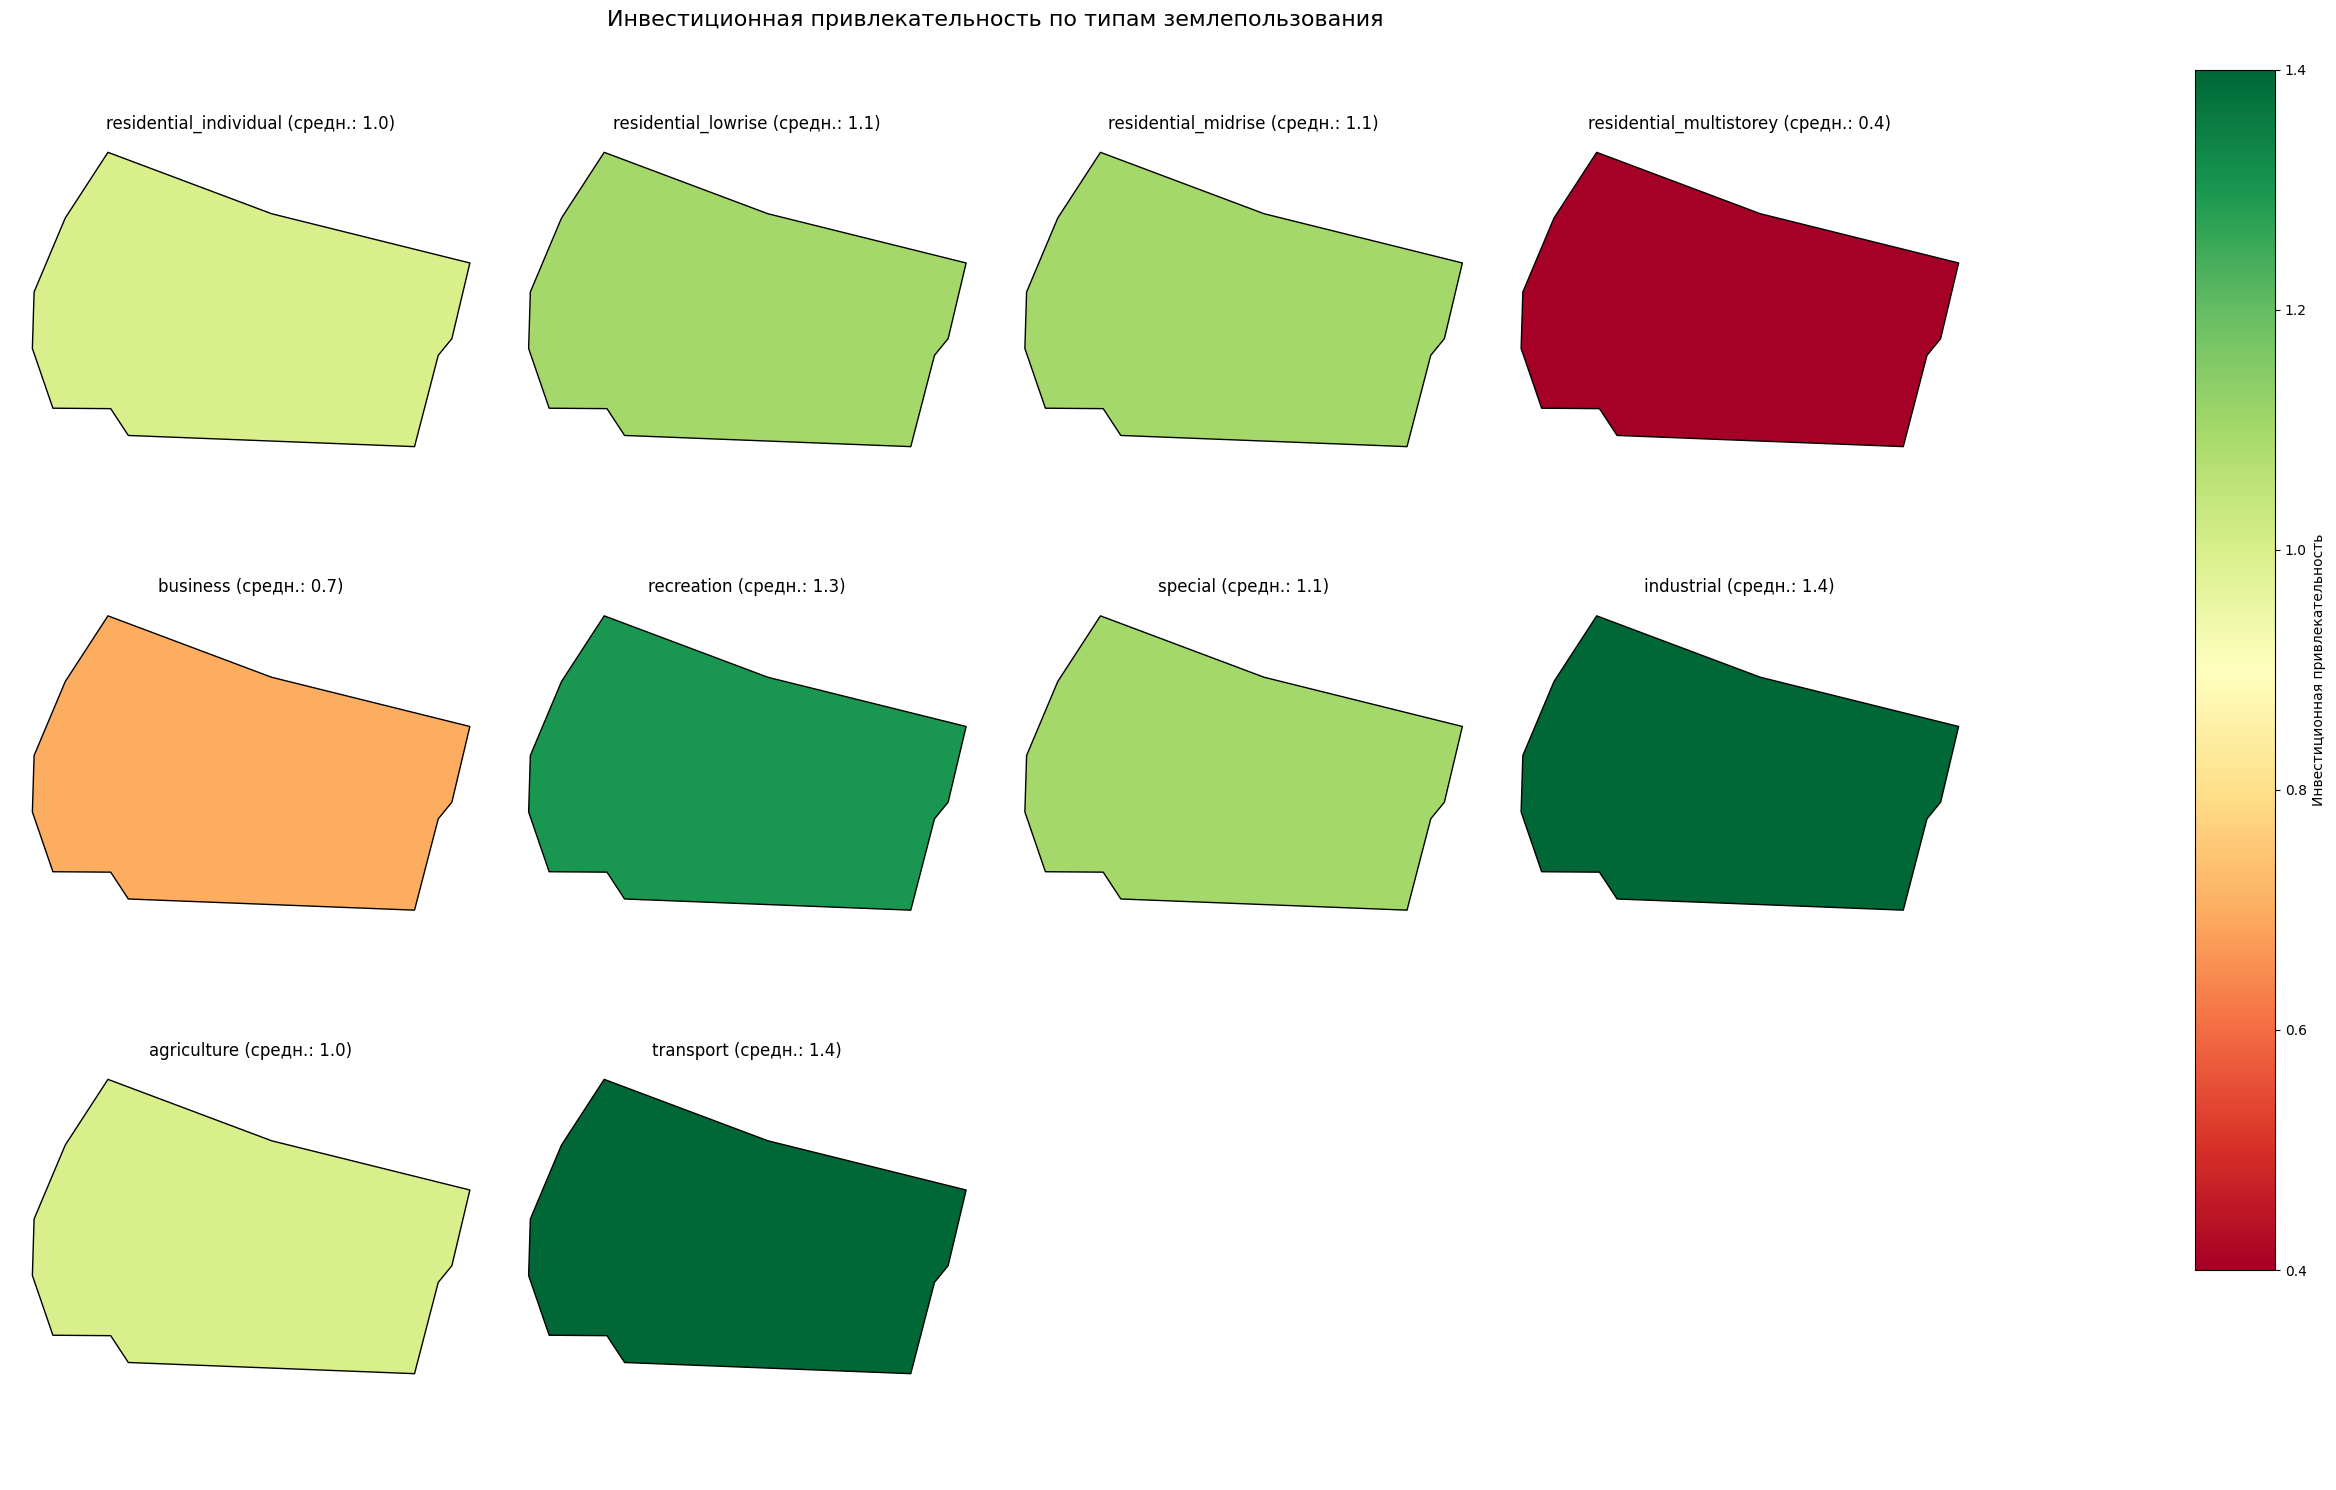

In [2]:
from urbanomy.methods.investment_potential import LandUseInvestmentAnalyzer

# custom_weights = {
#     'residential_individual': {
#         'Население': 1.0,
#         'default': 1.0
#     }
# }

analyzer = LandUseInvestmentAnalyzer(weights=None)
gdf = analyzer.compute_scores(polygon_gdf)
fig = analyzer.visualize_investment_maps(gdf)
plt.show()

In [ ]:
# project_id = 72
# params = {
#     "year": 2024,
#     "source": "OSM"
# }

# territory_context_response = requests.get(
#     f"{URBAN_API}/projects/{project_id}/context/functional_zones",
#     params=params
# )

# if territory_context_response.status_code != 200:
#     raise Exception("Ошибка при получении геометрии территории")

# territory_data = territory_context_response.json()

# # Проверяем, что структура — FeatureCollection
# if "features" not in territory_data:
#     raise Exception("Ожидалась структура FeatureCollection с ключом 'features'")

# # Преобразуем все features в GeoDataFrame
# polygon_context_gdf = gpd.GeoDataFrame.from_features(territory_data["features"], crs=4326)
# polygon_context_gdf = polygon_context_gdf.to_crs(32636)

# # Преобразование мультиполигонов в отдельные полигоны
# polygon_context_gdf = polygon_context_gdf.explode(index_parts=False)

# # Сброс индекса
# polygon_context_gdf = polygon_context_gdf.reset_index(drop=True)
# polygon_context_gdf